# 🏙️ Municipal Grievance Intelligence System

## 📌 Problem Statement
Municipalities collect grievance data but lack analytical dashboards to identify recurring issues like water, roads, and infrastructure.

## 🎯 Objective
To analyze grievance data and extract insights such as:
- Most common complaint categories
- Geographic hotspots
- Resolution efficiency
- Time-based trends

In [15]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 📥 Loading Dataset (Streaming Large File)

We load the dataset efficiently using a streaming approach to handle large JSON files.

In [16]:
with open("grievance_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert to dataframe
df = pd.json_normalize(data)

print("Shape:", df.shape)
df.head()

Shape: (175784, 17)


,_id,CategoryV7,UserCode,dist_name,org_code,pincode,registration_no,remarks_text,sex,state,subject_content_text,v7_target,DiaryDate.$date,closing_date.$date,recvd_date.$date,resolution_date.$date,closing_date
0,MORLY/E/2023/0000001,11578.0,110124,North 24 Parganas,MORLY,700130,MORLY/E/2023/0000001,"As per railway record, there is no authoriz...",M,WB,"Railways, ( Railway Board) >> Miscellaneous\r\...",No,2023-01-01T00:00:19.977Z,2023-01-04T00:00:00Z,2023-01-01T00:00:19.977Z,2023-01-04T00:00:00Z,NaN
1,GOVUP/E/2023/0000001,NaN,45427,NaN,GOVUP,203001,GOVUP/E/2023/0000001,NaN,M,UP,XAXPX/X/X0X2X4X0X0\tREGARDING CBCID INSPECTION...,NaN,2023-01-01T00:01:29.78Z,2023-01-24T00:00:00Z,2023-01-01T00:01:28.567Z,NaN,NaN
2,MOLBR/E/2023/0000001,2369.0,1356254,Hyderabad,MOLBR,500023,MOLBR/E/2023/0000001,"Sir/Madam, With reference to Grievance no. XO...",M,TG,Labour and Employment >> PF Withdrawal >> Othe...,No,2023-01-01T00:01:45.593Z,2023-01-12T00:00:00Z,2023-01-01T00:01:45.593Z,2023-01-12T00:00:00Z,NaN
3,MOLBR/E/2023/0000002,2379.0,1092136,Nagpur,MOLBR,440001,MOLBR/E/2023/0000002,Please submit establishment clarification let...,M,MH,Labour and Employment >> Pension >> Others\r\n...,No,2023-01-01T00:02:07.247Z,2023-01-06T00:00:00Z,2023-01-01T00:02:07.247Z,2023-01-06T00:00:00Z,NaN
4,GOVUP/E/2023/0000002,NaN,45427,NaN,GOVUP,203001,GOVUP/E/2023/0000002,NaN,M,UP,XAXPX/X/X0X2X4X0X8\tREGARDING CBCID INSPECTION...,NaN,2023-01-01T00:02:25.663Z,2023-01-24T00:00:00Z,2023-01-01T00:02:24.913Z,NaN,NaN


## 🧹 Data Cleaning & Feature Engineering

We prepare the dataset for analysis by:
- Converting date columns
- Creating resolution time
- Extracting meaningful complaint categories

In [17]:
# Convert date columns (correct columns)
df['recvd_date'] = pd.to_datetime(
    df['recvd_date.$date'], 
    format='ISO8601', 
    errors='coerce'
)

df['closing_date'] = pd.to_datetime(
    df['closing_date.$date'], 
    format='ISO8601', 
    errors='coerce'
)

# Create resolution time
df['resolution_days'] = (df['closing_date'] - df['recvd_date']).dt.days

# Extract main category
df['main_category'] = df['subject_content_text'].astype(str).str.split(">>").str[0].str.strip()

# Check
df[['recvd_date', 'closing_date', 'resolution_days', 'main_category']].head()

,recvd_date,closing_date,resolution_days,main_category
0,2023-01-01 00:00:19.977000+00:00,2023-01-04 00:00:00+00:00,2.0,"Railways, ( Railway Board)"
1,2023-01-01 00:01:28.567000+00:00,2023-01-24 00:00:00+00:00,22.0,XAXPX/X/X0X2X4X0X0\tREGARDING CBCID INSPECTION...
2,2023-01-01 00:01:45.593000+00:00,2023-01-12 00:00:00+00:00,10.0,Labour and Employment
3,2023-01-01 00:02:07.247000+00:00,2023-01-06 00:00:00+00:00,4.0,Labour and Employment
4,2023-01-01 00:02:24.913000+00:00,2023-01-24 00:00:00+00:00,22.0,XAXPX/X/X0X2X4X0X8\tREGARDING CBCID INSPECTION...


## 📊 Top Complaint Categories

Analyzing the most frequent grievance types reported by citizens.

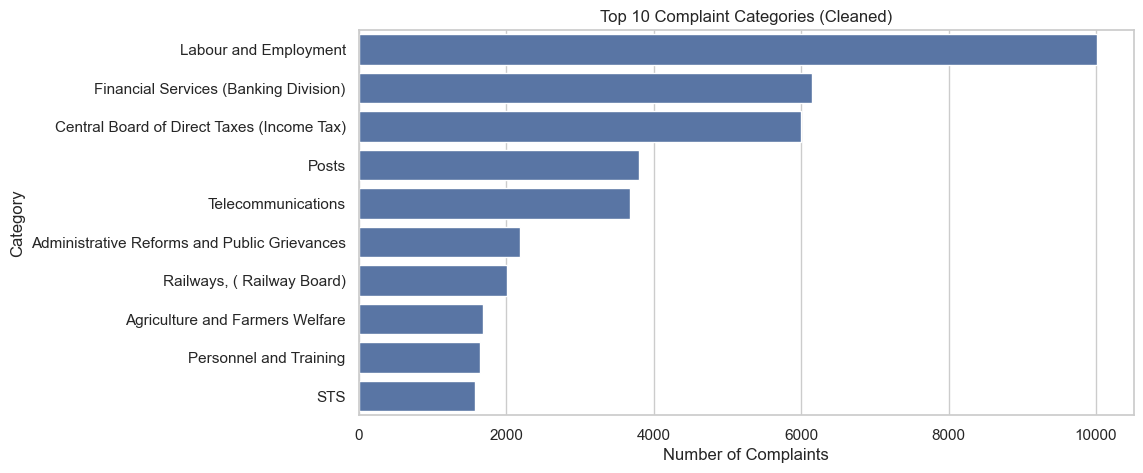

main_category
Labour and Employment                           10012
Financial Services (Banking Division)            6153
Central Board of Direct Taxes (Income Tax)       5995
Posts                                            3796
Telecommunications                               3674
Administrative Reforms and Public Grievances     2185
Railways, ( Railway Board)                       2013
Agriculture and Farmers Welfare                  1686
Personnel and Training                           1640
STS                                              1580
Name: count, dtype: int64


In [19]:
# Remove garbage / encoded categories
clean_df = df[
    ~df['main_category'].str.contains('XAXPX|PG/', na=False)
]

# Get top categories from cleaned data
top_categories = clean_df['main_category'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top 10 Complaint Categories (Cleaned)")
plt.xlabel("Number of Complaints")
plt.ylabel("Category")
plt.show()

print(top_categories)

## 📍 State-wise Complaint Distribution

Analyzing which states have the highest number of grievances.

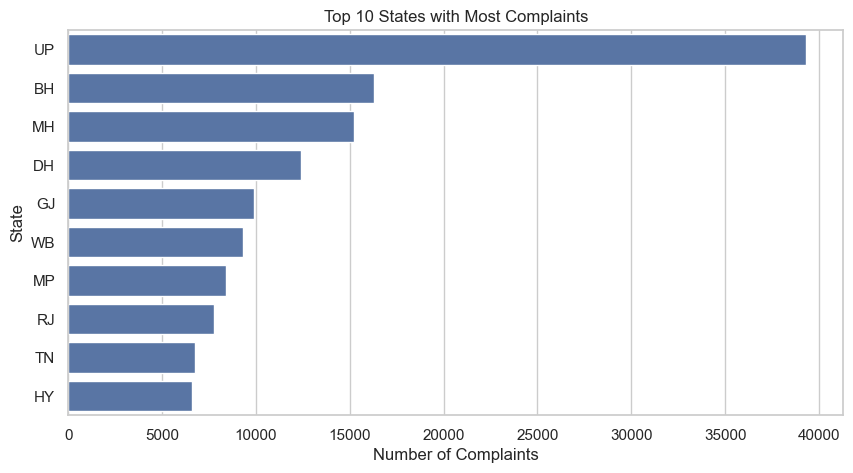

state
UP    39334
BH    16295
MH    15206
DH    12380
GJ     9891
WB     9305
MP     8386
RJ     7735
TN     6735
HY     6613
Name: count, dtype: int64


In [20]:
top_states = df['state'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index)

plt.title("Top 10 States with Most Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()

print(top_states)

## 🗺️ District-wise Complaint Hotspots

Identifying districts with the highest complaint density.

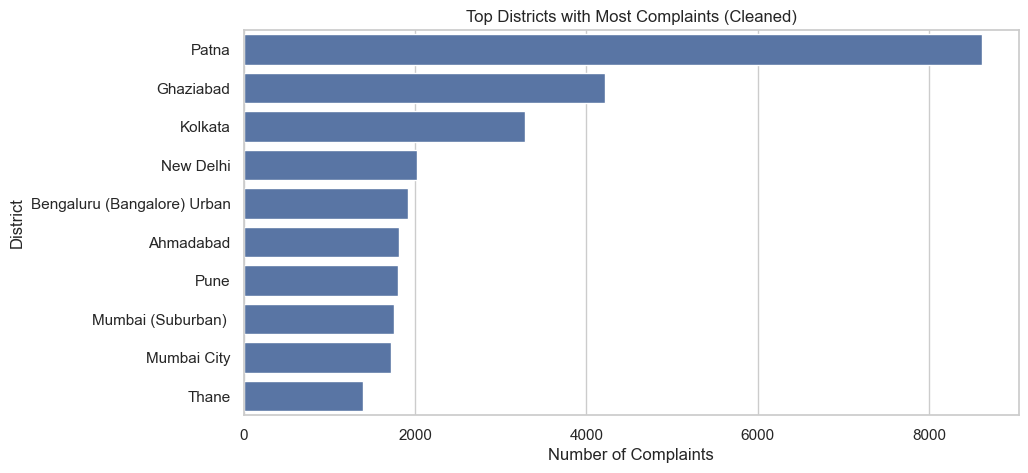

dist_name
Patna                          8611
Ghaziabad                      4219
Kolkata                        3283
New Delhi                      2020
Bengaluru (Bangalore) Urban    1917
Ahmadabad                      1812
Pune                           1797
Mumbai (Suburban)              1749
Mumbai City                    1716
Thane                          1392
Name: count, dtype: int64


In [22]:
# Remove invalid district values
clean_df = df[
    df['dist_name'].notna() &
    (df['dist_name'] != 'No District/Not Known')
]

top_districts = clean_df['dist_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_districts.values, y=top_districts.index)

plt.title("Top Districts with Most Complaints (Cleaned)")
plt.xlabel("Number of Complaints")
plt.ylabel("District")
plt.show()

print(top_districts)

## 📅 Daily Complaint Trend

Since the dataset is limited to January 2023, we analyze daily trends  
to understand variations in complaint volume across the month.

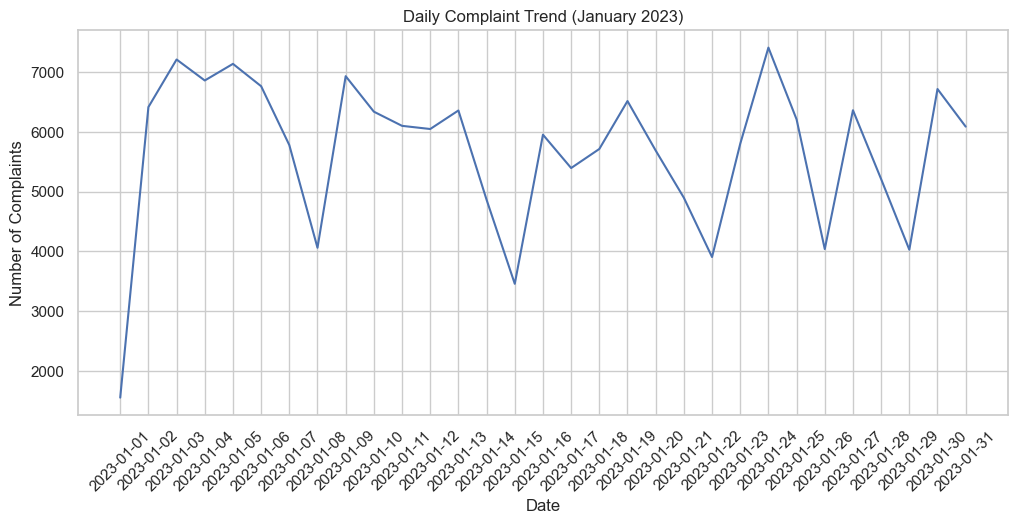

In [26]:
df['day'] = df['recvd_date'].dt.strftime('%Y-%m-%d')

daily = df.groupby('day').size()

plt.figure(figsize=(12,5))
sns.lineplot(x=daily.index, y=daily.values)

plt.title("Daily Complaint Trend (January 2023)")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

## ⏱️ Resolution Time Analysis

Analyzing how long it takes to resolve complaints.

This helps evaluate the efficiency of grievance redressal systems.

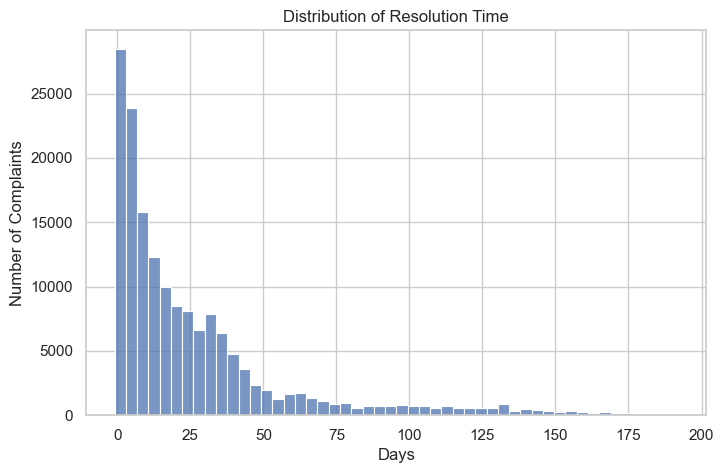

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['resolution_days'].dropna(), bins=50)

plt.title("Distribution of Resolution Time")
plt.xlabel("Days")
plt.ylabel("Number of Complaints")
plt.show()

## 🧮 Average Resolution Time by State

Analyzing which states take longer to resolve complaints.

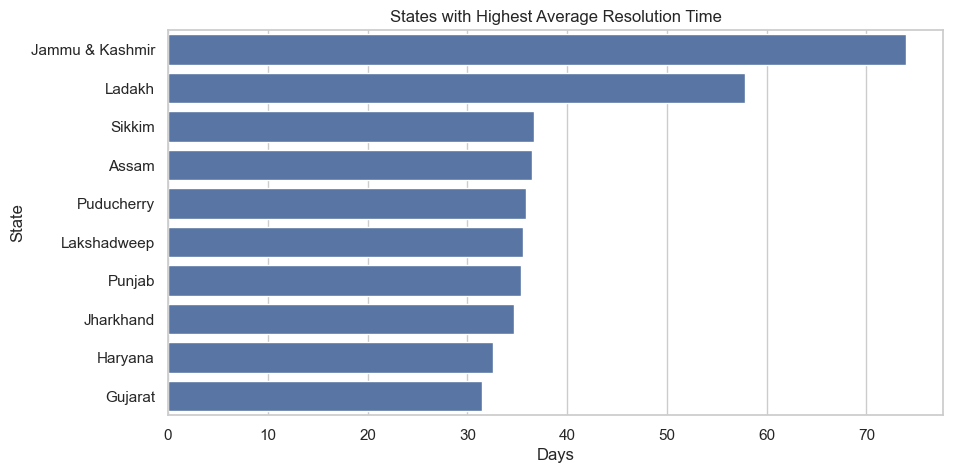

state_full
Jammu & Kashmir    73.988206
Ladakh             57.875000
Sikkim             36.692308
Assam              36.450702
Puducherry         35.906832
Lakshadweep        35.600000
Punjab             35.408223
Jharkhand          34.666032
Haryana            32.571329
Gujarat            31.422137
Name: resolution_days, dtype: float64


In [32]:
# Step 1: Clean state column
df['state'] = df['state'].astype(str).str.strip()

# Step 2: Mapping (short → full names)
state_map = {
    "UP": "Uttar Pradesh",
    "MH": "Maharashtra",
    "BH": "Bihar",
    "RJ": "Rajasthan",
    "MP": "Madhya Pradesh",
    "GJ": "Gujarat",
    "WB": "West Bengal",
    "TN": "Tamil Nadu",
    "HY": "Haryana",
    "PB": "Punjab",
    "AS": "Assam",
    "SK": "Sikkim",
    "JH": "Jharkhand",
    "DL": "Delhi",
    "LD": "Lakshadweep",
    "JK": "Jammu & Kashmir",
    "LK": "Ladakh",
    "PC": "Puducherry"
}

# Step 3: Apply mapping
df['state_full'] = df['state'].map(state_map)

# Step 4: Remove missing / unknown
df_clean = df[
    df['state_full'].notna()
]

# Step 5: Analysis
avg_resolution = df_clean.groupby('state_full')['resolution_days'].mean().sort_values(ascending=False).head(10)

# Step 6: Plot
plt.figure(figsize=(10,5))
sns.barplot(x=avg_resolution.values, y=avg_resolution.index)

plt.title("States with Highest Average Resolution Time")
plt.xlabel("Days")
plt.ylabel("State")
plt.show()

print(avg_resolution)

# ✅ Conclusion

## Key Findings:
- Labour and Employment is the most common complaint category
- Uttar Pradesh has the highest complaint volume
- Districts like Patna and Ghaziabad are major hotspots
- Most complaints are resolved quickly, but some take significantly longer
- States like Jammu & Kashmir and Ladakh show higher resolution delays

## 🚀 Final Insight:
Data-driven grievance analysis helps identify inefficiencies, improve response times, and enable better governance decisions.